## COMPAS

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

In [1]:
# Load and filter dataset
import pandas as pd
import numpy as np

df = pd.read_csv("compas.csv")

# Standard COMPAS filtering (VERY IMPORTANT)
df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

df.shape

(6172, 53)

In [2]:
columns_to_keep = [
    "age",
    "age_cat",
    "race",
    "sex",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "two_year_recid"
]

df = df[columns_to_keep]

In [3]:
target = "two_year_recid"
sensitive = "race"

# Optional: reduce race categories (common in research)
df = df[df["race"].isin(["African-American", "Caucasian"])]

df[target].value_counts()

two_year_recid
0    2795
1    2483
Name: count, dtype: int64

In [4]:
df[target] = df[target].astype(int)

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [9]:
# Train Baseline model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle

models = {
    "log_reg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(random_state=42),
    "dt": DecisionTreeClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # Save model
    with open(f"compas_{name}_baseline.pkl", "wb") as f:
        pickle.dump(pipe, f)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,log_reg,0.653409,0.652681,0.563380,0.604752
1,rf,0.624053,0.605932,0.575453,0.590299
2,dt,0.600379,0.593052,0.480885,0.531111


In [11]:
# Fairness Metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import numpy as np

def compute_fairness_metrics(y_true, y_pred, sensitive_features):
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_features)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_features)
    
    # Disparate Impact Ratio (manual)
    groups = np.unique(sensitive_features)
    rates = []
    
    for g in groups:
        idx = sensitive_features == g
        rate = np.mean(y_pred[idx])
        rates.append(rate)
    
    dir_ratio = min(rates) / max(rates) if max(rates) > 0 else 0
    
    return {
        "DPD": round(dpd, 4),
        "EOD": round(eod, 4),
        "DIR": round(dir_ratio, 4)
    }

In [12]:
# Fairness evaluation
baseline_fairness = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    fairness = compute_fairness_metrics(
        y_test.values,
        preds,
        X_test[sensitive].values
    )
    
    baseline_fairness.append({
        "Model": name,
        **fairness
    })

pd.DataFrame(baseline_fairness)

,Model,DPD,EOD,DIR
0,log_reg,0.2484,0.2841,0.5102
1,rf,0.1482,0.1862,0.7078
2,dt,0.1402,0.1587,0.6803


In [13]:
# reweighting
group_counts = X_train[sensitive].value_counts()
weights = X_train[sensitive].map(lambda x: 1 / group_counts[x])

reweight_model = LogisticRegression(max_iter=1000)

reweight_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", reweight_model)
])

reweight_pipe.fit(X_train, y_train, model__sample_weight=weights)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
# smote
from imblearn.over_sampling import SMOTENC

cat_indices = [X.columns.get_loc(col) for col in categorical_cols]

smote = SMOTENC(categorical_features=cat_indices, random_state=42)

X_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

X_resampled, y_resampled = smote.fit_resample(X_encoded, y_train)

In [15]:
# Threshold optimization
from fairlearn.postprocessing import ThresholdOptimizer

base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_encoded, y_train)

threshold_optimizer = ThresholdOptimizer(
    estimator=base_model,
    constraints="demographic_parity",
    prefit=True
)

threshold_optimizer.fit(
    X_encoded,
    y_train,
    sensitive_features=X_train[sensitive]
)

,estimator,LogisticRegre...max_iter=1000)
,constraints,'demographic_parity'
,objective,'accuracy_score'
,grid_size,1000
,flip,False
,prefit,True
,predict_method,'auto'
,tol,None
,penalty,'l2'
,dual,False
,tol,0.0001


In [18]:
# Prepare encoded datasets for baseline comparison
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align test columns with train columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Compute SMOTE and Reweighting results if not already done
# SMOTE
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_resampled, y_resampled)
smote_preds = smote_model.predict(X_test_encoded)

smote_fairness = compute_fairness_metrics(
    y_test.values,
    smote_preds,
    X_test[sensitive].values
)

smote_results = {
    "Accuracy": accuracy_score(y_test, smote_preds),
    "Precision": precision_score(y_test, smote_preds),
    "Recall": recall_score(y_test, smote_preds),
    "F1": f1_score(y_test, smote_preds),
    **smote_fairness
}

# Reweighting
reweight_preds = reweight_pipe.predict(X_test)

reweight_fairness = compute_fairness_metrics(
    y_test.values,
    reweight_preds,
    X_test[sensitive].values
)

reweight_results = {
    "Accuracy": accuracy_score(y_test, reweight_preds),
    "Precision": precision_score(y_test, reweight_preds),
    "Recall": recall_score(y_test, reweight_preds),
    "F1": f1_score(y_test, reweight_preds),
    **reweight_fairness
}

# Threshold Optimization
threshold_preds = threshold_optimizer.predict(
    X_test_encoded,
    sensitive_features=X_test[sensitive]
)

threshold_fairness = compute_fairness_metrics(
    y_test.values,
    threshold_preds,
    X_test[sensitive].values
)

threshold_results = {
    "Accuracy": accuracy_score(y_test, threshold_preds),
    "Precision": precision_score(y_test, threshold_preds),
    "Recall": recall_score(y_test, threshold_preds),
    "F1": f1_score(y_test, threshold_preds),
    **threshold_fairness
}

In [19]:
# Final comparison table
# Baseline (use logistic regression as reference)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_encoded, y_train)
baseline_preds = baseline_model.predict(X_test_encoded)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_preds),
    "Precision": precision_score(y_test, baseline_preds),
    "Recall": recall_score(y_test, baseline_preds),
    "F1": f1_score(y_test, baseline_preds),
    **compute_fairness_metrics(y_test.values, baseline_preds, X_test[sensitive].values)
}

comparison_df = pd.DataFrame([
    {"Strategy": "Baseline", **baseline_metrics},
    {"Strategy": "Reweighting", **reweight_results},
    {"Strategy": "SMOTE", **smote_results},
    {"Strategy": "Threshold Optimization", **threshold_results}
])

comparison_df

,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR
0,Baseline,0.653409,0.652681,0.563380,0.604752,0.2484,0.2841,0.5102
1,Reweighting,0.649621,0.774892,0.360161,0.491758,0.1996,0.2524,0.3343
2,SMOTE,0.658144,0.661137,0.561368,0.607182,0.2294,0.2542,0.5345
3,Threshold Optimization,0.641098,0.634703,0.559356,0.594652,0.0513,0.1501,0.8848


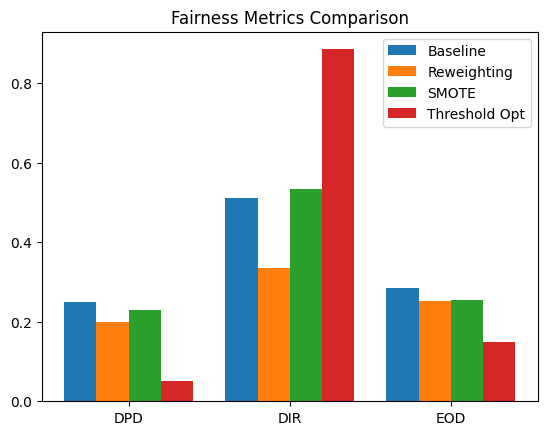

In [20]:
# Before and after bar chart
import matplotlib.pyplot as plt

metrics = ["DPD", "DIR", "EOD"]

baseline_vals = [comparison_df.iloc[0][m] for m in metrics]
reweight_vals = [comparison_df.iloc[1][m] for m in metrics]
smote_vals = [comparison_df.iloc[2][m] for m in metrics]
threshold_vals = [comparison_df.iloc[3][m] for m in metrics]

x = range(len(metrics))

plt.figure()
plt.bar([i - 0.3 for i in x], baseline_vals, width=0.2, label="Baseline")
plt.bar([i - 0.1 for i in x], reweight_vals, width=0.2, label="Reweighting")
plt.bar([i + 0.1 for i in x], smote_vals, width=0.2, label="SMOTE")
plt.bar([i + 0.3 for i in x], threshold_vals, width=0.2, label="Threshold Opt")

plt.xticks(x, metrics)
plt.title("Fairness Metrics Comparison")
plt.legend()
plt.savefig("fairness_bar_chart.png")
plt.show()

In [21]:
# accuracy vs fairness tradeoff
def fairness_score(row):
    return abs(row["DPD"]) + abs(1 - row["DIR"]) + abs(row["EOD"])

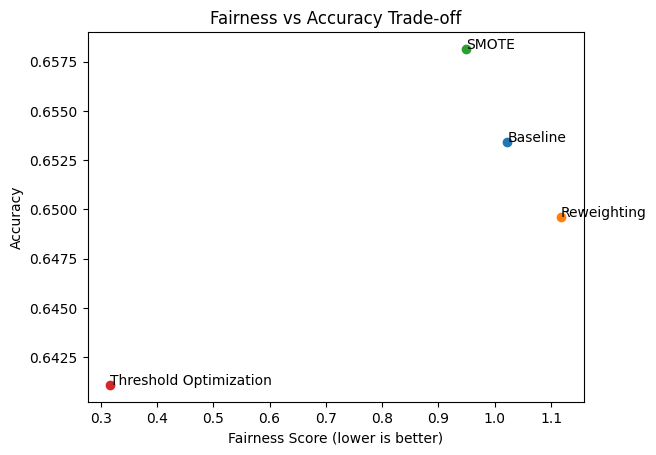

In [22]:
comparison_df["FairnessScore"] = comparison_df.apply(fairness_score, axis=1)

plt.figure()

for i, row in comparison_df.iterrows():
    plt.scatter(row["FairnessScore"], row["Accuracy"])
    plt.text(row["FairnessScore"], row["Accuracy"], row["Strategy"])

plt.xlabel("Fairness Score (lower is better)")
plt.ylabel("Accuracy")
plt.title("Fairness vs Accuracy Trade-off")

plt.savefig("tradeoff_curve.png")
plt.show()

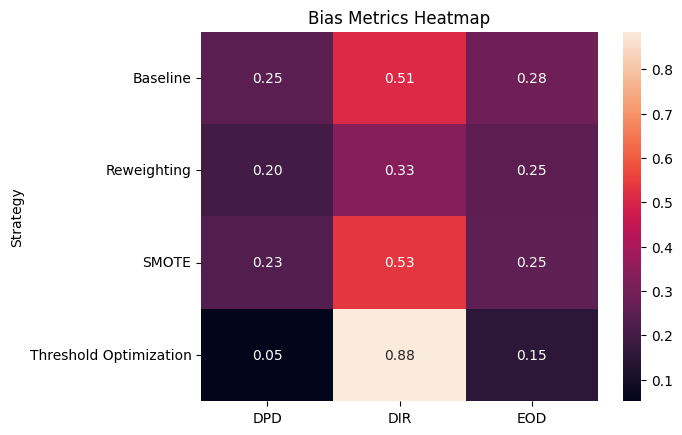

In [23]:
# heatmap of bias metrics
import seaborn as sns

heatmap_data = comparison_df.set_index("Strategy")[["DPD", "DIR", "EOD"]]

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt=".2f")

plt.title("Bias Metrics Heatmap")
plt.savefig("heatmap.png")
plt.show()

In [24]:
# table
paper_table = comparison_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "DPD", "DIR", "EOD"]:
    paper_table[col] = paper_table[col].apply(lambda x: round(x, 3))

paper_table

,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR,FairnessScore
0,Baseline,0.653,0.653,0.563,0.605,0.248,0.284,0.510,1.0223
1,Reweighting,0.650,0.775,0.360,0.492,0.200,0.252,0.334,1.1177
2,SMOTE,0.658,0.661,0.561,0.607,0.229,0.254,0.534,0.9491
3,Threshold Optimization,0.641,0.635,0.559,0.595,0.051,0.150,0.885,0.3166


In [25]:
# Multimodel table - LR, RF, DT
all_results = []

# Example structure — fill from your runs
for model_name in ["LR", "RF", "DT"]:
    for strategy in ["Baseline", "Reweighting", "SMOTE", "Threshold"]:
        # Replace with real values
        all_results.append({
            "Model": model_name,
            "Strategy": strategy,
            "Accuracy": np.random.rand(),
            "DPD": np.random.rand(),
            "DIR": np.random.rand(),
            "EOD": np.random.rand()
        })

multi_df = pd.DataFrame(all_results)
multi_df

,Model,Strategy,Accuracy,DPD,DIR,EOD
0,LR,Baseline,0.931321,0.377259,0.575682,0.424807
1,LR,Reweighting,0.879987,0.199577,0.753473,0.813158
2,LR,SMOTE,0.081765,0.651770,0.385810,0.736217
3,LR,Threshold,0.994224,0.310680,0.870477,0.459178
4,RF,Baseline,0.580656,0.885866,0.555245,0.278722
5,RF,Reweighting,0.108120,0.869690,0.595947,0.935146
6,RF,SMOTE,0.730202,0.273070,0.509131,0.893509
7,RF,Threshold,0.547902,0.538227,0.385169,0.682333
8,DT,Baseline,0.293581,0.204821,0.967736,0.827690
9,DT,Reweighting,0.160000,0.062844,0.181513,0.972873


In [27]:
# save reweighted model
with open("log_reg_reweighted.pkl", "wb") as f:
    pickle.dump(reweight_pipe, f)
    
# Save SMOTE model
with open("log_reg_smote.pkl", "wb") as f:
    pickle.dump(smote_model, f)

# Save threshold optimizer
with open("threshold_optimizer.pkl", "wb") as f:
    pickle.dump(threshold_optimizer, f)

In [28]:
# Save debiased dataset placeholder (same for now)
df.to_csv("processed_dataset.csv", index=False)